# Convert Image to HSV and LAB

## Objective

- Chuyển đổi ảnh từ không gian màu BGR sang HSV và LAB.
- Trực quan hóa ảnh HSV và LAB.
- Tách và hiển thị các kênh màu của HSV: Hue, Saturation, Value.
- Tách và hiển thị các kênh màu của LAB: Lightness, A, B.
- So sánh đặc điểm của BGR, HSV và LAB.
- Giải thích sự khác nhau khi hiển thị trực tiếp ma trận HSV và LAB so với ảnh màu thông thường.

In [44]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [45]:
# Thêm thư mục src vào Python path
SRC_DIR = Path("../src")
sys.path.append(str(SRC_DIR))

from color_space import convert_to_hsv
from color_space import convert_to_lab
from color_space import split_hsv_channels
from color_space import split_lab_channels


# Chọn 20 ảnh

In [46]:
INPUT_DIR = Path("../data/input")

image_paths = sorted(INPUT_DIR.glob("*.jpg"))[:20]

print(f"Số lượng ảnh được chọn: {len(image_paths)}")

Số lượng ảnh được chọn: 20


# Đọc 20 ảnh

In [59]:
images = {}

for image_path in image_paths:
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(f"Không thể đọc ảnh: {image_path}")

    images[image_path.name] = image
print(f"Số lượng ảnh đã đọc: {len(images)}")


Số lượng ảnh đã đọc: 20


# Hiển thị 20 ảnh

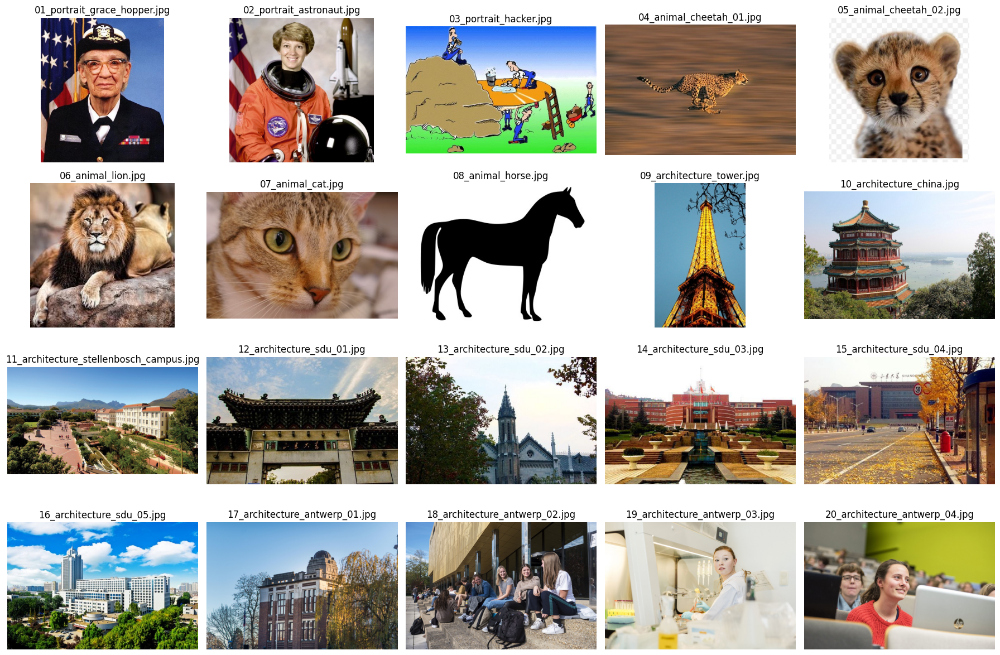

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(18, 12))

for ax, (image_name, image) in zip(axes.ravel(), images.items()):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image_rgb)
    ax.set_title(image_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

# BGR -> HSV

In [49]:
hsv_images = {}

for image_name, image in images.items():
    hsv_images[image_name] = convert_to_hsv(image)

print(f"Số lượng ảnh đã chuyển sang HSV: {len(hsv_images)}")

Số lượng ảnh đã chuyển sang HSV: 20


# Hiển thị kết quả ảnh HSV

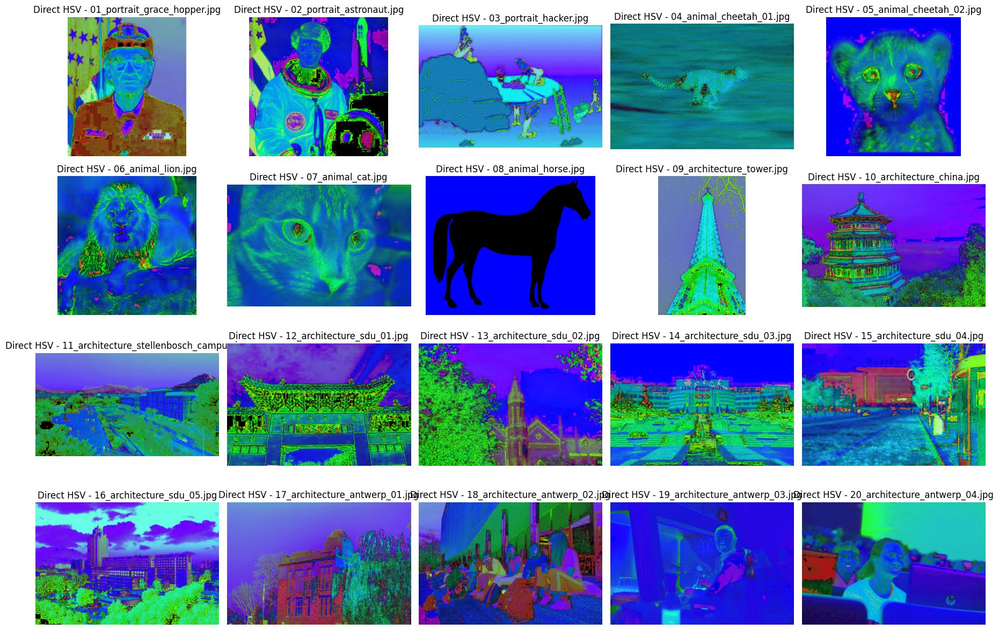

In [50]:
# Hiển thị trực tiếp ma trận HSV để quan sát sự khác biệt
fig, axes = plt.subplots(4, 5, figsize=(18, 12))

for ax, (image_name, hsv) in zip(axes.ravel(), hsv_images.items()):
    ax.imshow(hsv)
    ax.set_title(f"Direct HSV - {image_name}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# BGR -> LAB

In [51]:
lab_images = {}

for image_name, image in images.items():
    lab_images[image_name] = convert_to_lab(image)

print(f"Số lượng ảnh đã chuyển sang LAB: {len(lab_images)}")

Số lượng ảnh đã chuyển sang LAB: 20


# Hiển thị kết quả ảnh LAB

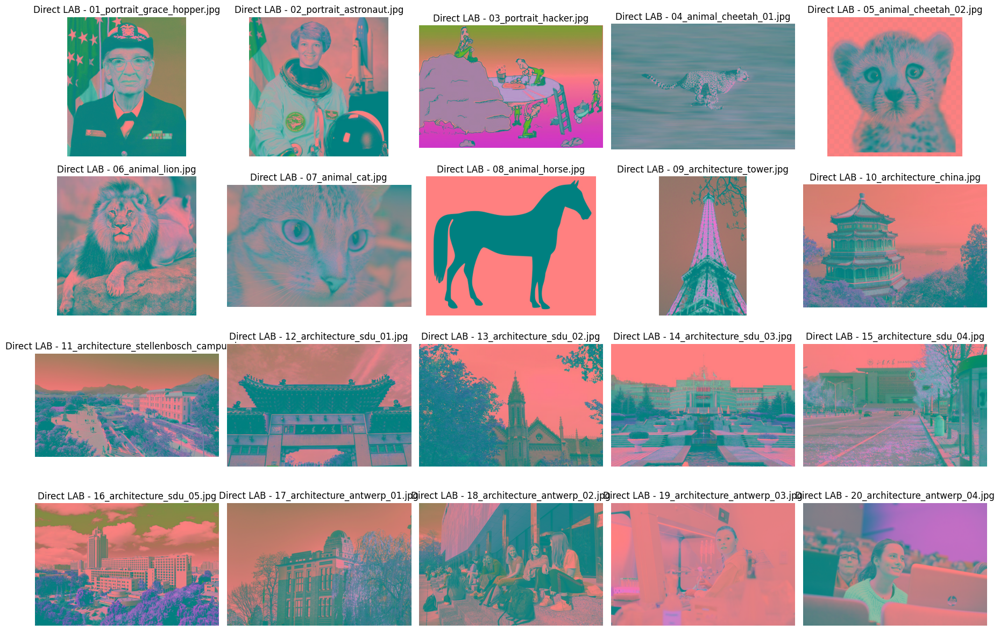

In [52]:
# Hiển thị trực tiếp ma trận LAB
fig, axes = plt.subplots(4, 5, figsize=(18, 12))

for ax, (image_name, lab) in zip(axes.ravel(), lab_images.items()):
    ax.imshow(lab)
    ax.set_title(f"Direct LAB - {image_name}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Tách H/S/V

In [53]:
hsv_channels = {}

for image_name, hsv in hsv_images.items():
    hue, saturation, value = split_hsv_channels(hsv)

    hsv_channels[image_name] = {
        "Hue": hue,
        "Saturation": saturation,
        "Value": value
    }

print(f"Số lượng ảnh đã tách channel HSV: {len(hsv_channels)}")

Số lượng ảnh đã tách channel HSV: 20


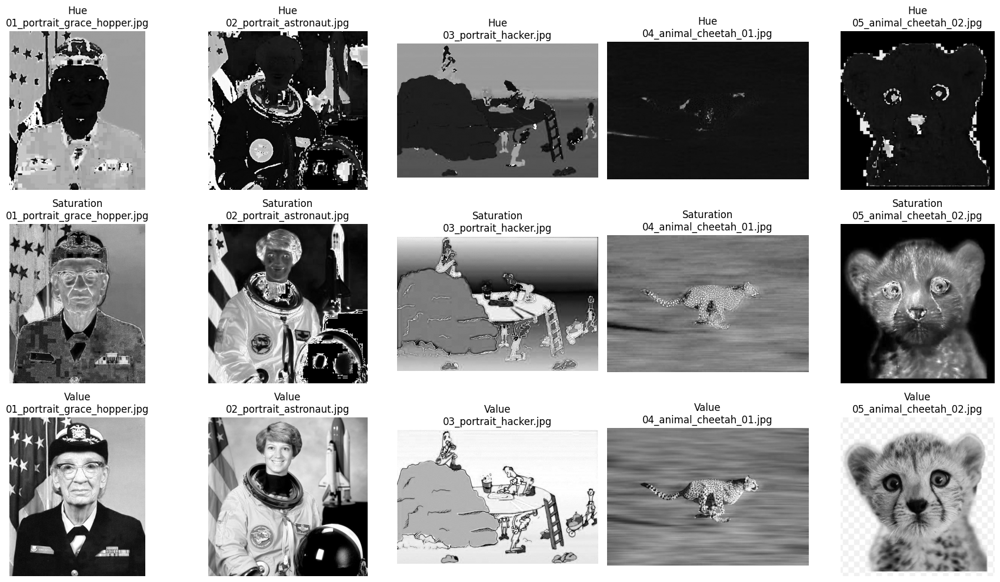

In [63]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))

selected_images = list(hsv_channels.items())[:5]

for row, channel_name in enumerate(["Hue", "Saturation", "Value"]):
    for col, (image_name, channels) in enumerate(selected_images):
        axes[row, col].imshow(channels[channel_name], cmap="gray")
        axes[row, col].set_title(f"{channel_name}\n{image_name}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


# Tách L/A/B

In [55]:
lab_channels = {}

for image_name, lab in lab_images.items():
    lightness, channel_a, channel_b = split_lab_channels(lab)

    lab_channels[image_name] = {
        "Lightness": lightness,
        "A": channel_a,
        "B": channel_b
    }

print(f"Số lượng ảnh đã tách channel LAB: {len(lab_channels)}")

Số lượng ảnh đã tách channel LAB: 20


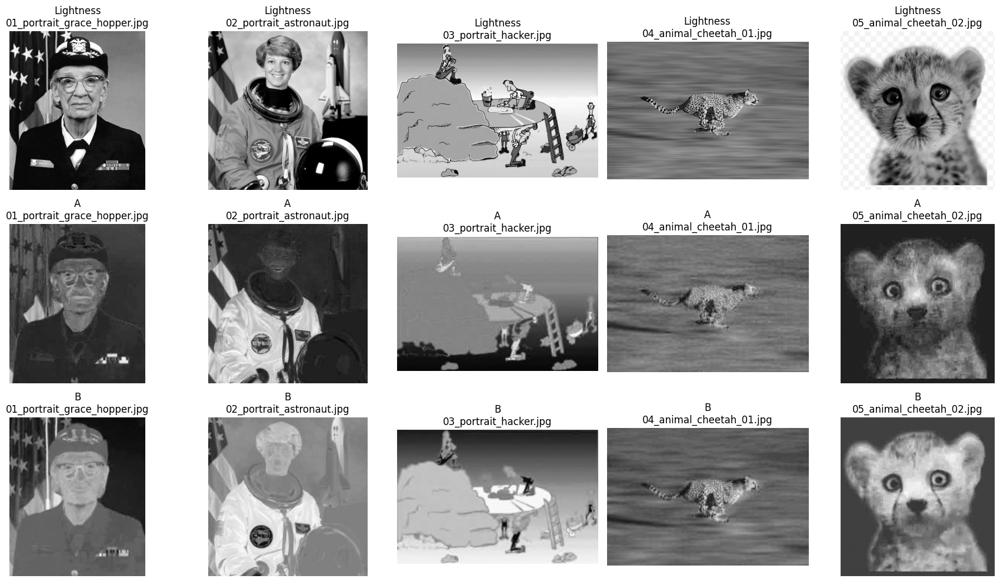

In [56]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))

selected_images = list(lab_channels.items())[:5]

for row, channel_name in enumerate(["Lightness", "A", "B"]):
    for col, (image_name, channels) in enumerate(selected_images):
        axes[row, col].imshow(channels[channel_name], cmap="gray")
        axes[row, col].set_title(f"{channel_name}\n{image_name}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# So sánh BGR, HSV và LAB

In [57]:
comparison_data = []

for image_name in images:
    image = images[image_name]
    hsv = hsv_images[image_name]
    lab = lab_images[image_name]

    comparison_data.append({
        "Image": image_name,
        "BGR Shape": image.shape,
        "HSV Shape": hsv.shape,
        "LAB Shape": lab.shape
    })

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df.style.hide(axis="index"))

Image,BGR Shape,HSV Shape,LAB Shape
01_portrait_grace_hopper.jpg,"(600, 512, 3)","(600, 512, 3)","(600, 512, 3)"
02_portrait_astronaut.jpg,"(512, 512, 3)","(512, 512, 3)","(512, 512, 3)"
03_portrait_hacker.jpg,"(354, 531, 3)","(354, 531, 3)","(354, 531, 3)"
04_animal_cheetah_01.jpg,"(343, 502, 3)","(343, 502, 3)","(343, 502, 3)"
05_animal_cheetah_02.jpg,"(787, 762, 3)","(787, 762, 3)","(787, 762, 3)"
06_animal_lion.jpg,"(256, 256, 3)","(256, 256, 3)","(256, 256, 3)"
07_animal_cat.jpg,"(300, 451, 3)","(300, 451, 3)","(300, 451, 3)"
08_animal_horse.jpg,"(328, 400, 3)","(328, 400, 3)","(328, 400, 3)"
09_architecture_tower.jpg,"(600, 377, 3)","(600, 377, 3)","(600, 377, 3)"
10_architecture_china.jpg,"(427, 640, 3)","(427, 640, 3)","(427, 640, 3)"


## Comparison of BGR, HSV and LAB

| Color Space | Channel 1 | Channel 2 | Channel 3 | Main Characteristics |
|-------------|-----------|-----------|-----------|----------------------|
| **BGR**     | B (Blue)  | G (Green) | R (Red)   | Biểu diễn màu bằng ba kênh Blue, Green và Red. Đây là thứ tự kênh mặc định khi OpenCV đọc ảnh bằng `cv2.imread()`. |
| **HSV**     | H (Hue)   |S(Saturation)|V(Value) | Tách thông tin màu sắc thành Hue, Saturation và độ sáng Value. |
| **LAB**     |L(Lightness)| A          | B | Tách Lightness khỏi hai thành phần màu A và B. |

- Mặc dù cả ba không gian màu đều có 3 channel và giữ nguyên kích thước ảnh, ý nghĩa của từng channel là khác nhau.
- Vì vậy, không thể xem các channel của BGR, HSV và LAB là tương đương nhau.
### Channel Interpretation

- **BGR**
  - **B (Blue):** mức độ thành phần màu xanh dương.
  - **G (Green):** mức độ thành phần màu xanh lá.
  - **R (Red):** mức độ thành phần màu đỏ.

- **HSV**
  - **H (Hue):** loại màu.
  - **S (Saturation):** mức độ bão hòa của màu.
  - **V (Value):** mức độ sáng.

- HSV tách thông tin về sắc màu, độ bão hòa và độ sáng thành ba channel riêng biệt. Điều này giúp quan sát và phân tích các đặc điểm màu sắc của ảnh theo từng thành phần.
- **LAB**
  - **L (Lightness):** độ sáng.
  - **A:** thành phần màu trên trục xanh lá – đỏ.
  - **B:** thành phần màu trên trục xanh dương – vàng.
### Ý nghĩa của A và B

- **A channel:** thể hiện vị trí của màu trên trục xanh lá ↔ đỏ.
- **B channel:** thể hiện vị trí của màu trên trục xanh dương ↔ vàng.

A và B không phải là hai channel Blue và Red như trong BGR. Chúng là hai trục dùng để biểu diễn thông tin màu trong không gian LAB.

### Nhận xét

LAB tách thông tin về độ sáng **L (Lightness)** khỏi thông tin màu được biểu diễn bởi hai channel **A và B**.

## 10. Remarks

- Việc chuyển đổi từ BGR sang HSV và LAB không làm thay đổi kích thước ảnh; các ảnh vẫn giữ nguyên chiều cao, chiều rộng và 3 channel.
- HSV biểu diễn màu bằng Hue, Saturation và Value, giúp tách thông tin về sắc màu, độ bão hòa và độ sáng.
- LAB biểu diễn màu bằng Lightness, A và B, trong đó A và B là hai trục màu từ xanh lá đến đỏ và từ xanh dương đến vàng.
- Mặc dù BGR, HSV và LAB đều có 3 channel, ý nghĩa của các channel trong mỗi không gian màu là khác nhau.
- Khi hiển thị trực tiếp ma trận HSV hoặc LAB, màu sắc có thể khác ảnh màu thông thường vì các channel H/S/V hoặc L/A/B không phải là các channel RGB.